<a href="https://colab.research.google.com/github/tejoramvakada91-hub/DL/blob/main/DL_05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Epoch 0, Loss: 0.254485

Final Loss: 0.250347

--- XOR Predictions ---
Input: [0 0], Expected: 0, Predicted: 0
Input: [0 1], Expected: 1, Predicted: 0
Input: [1 0], Expected: 1, Predicted: 1
Input: [1 1], Expected: 0, Predicted: 1

All XOR combinations classified correctly: False


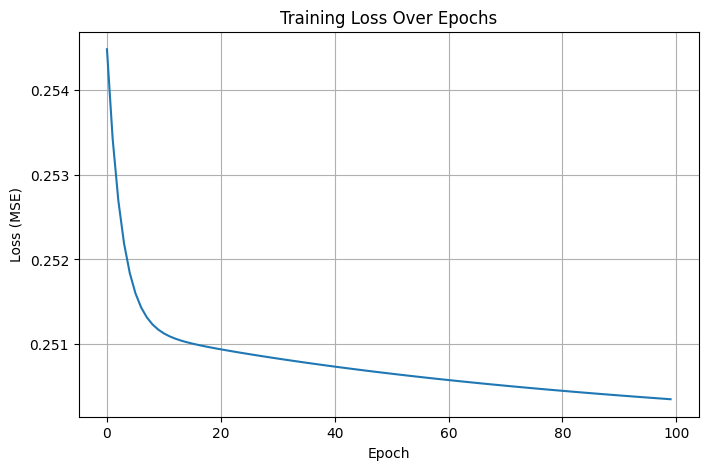

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define XOR inputs and outputs
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])
y = np.array([
    [0],
    [1],
    [1],
    [0]
])

# Activation function
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

# Reproducibility
np.random.seed(42)

# Network architecture
input_neurons = 2
hidden_neurons = 2
output_neurons = 1

# Initialize weights and biases (random for better learning)
w_hidden = np.random.uniform(-1, 1, (input_neurons, hidden_neurons))
b_hidden = np.random.uniform(-1, 1, (1, hidden_neurons))

w_output = np.random.uniform(-1, 1, (hidden_neurons, output_neurons))
b_output = np.random.uniform(-1, 1, (1, output_neurons))

# Training parameters
epochs = 100
learning_rate = 0.5
losses = []

# Training loop
for epoch in range(epochs):

    # ---- Forward Propagation ----
    hidden_input = np.dot(X, w_hidden) + b_hidden
    hidden_output = sigmoid(hidden_input)

    final_input = np.dot(hidden_output, w_output) + b_output
    predicted_output = sigmoid(final_input)

    # ---- Backpropagation ----
    error_output = y - predicted_output
    d_output = error_output * sigmoid_derivative(predicted_output)

    error_hidden = np.dot(d_output, w_output.T)
    d_hidden = error_hidden * sigmoid_derivative(hidden_output)

    # ---- Update Weights & Biases ----
    w_output += np.dot(hidden_output.T, d_output) * learning_rate
    b_output += np.sum(d_output, axis=0, keepdims=True) * learning_rate

    w_hidden += np.dot(X.T, d_hidden) * learning_rate
    b_hidden += np.sum(d_hidden, axis=0, keepdims=True) * learning_rate

    # ---- Loss ----
    loss = np.mean(np.square(y - predicted_output))
    losses.append(loss)

    if epoch % 1000 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.6f}")

print(f"\nFinal Loss: {loss:.6f}")

# ---- Final Prediction ----
hidden_output = sigmoid(np.dot(X, w_hidden) + b_hidden)
predicted_output = sigmoid(np.dot(hidden_output, w_output) + b_output)
predictions = np.round(predicted_output)

print("\n--- XOR Predictions ---")
for i in range(len(X)):
    print(f"Input: {X[i]}, Expected: {y[i][0]}, Predicted: {int(predictions[i][0])}")

print("\nAll XOR combinations classified correctly:",
      np.array_equal(predictions, y))

# ---- Plot Loss ----
plt.figure(figsize=(8, 5))
plt.plot(losses)
plt.title('Training Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.grid(True)
plt.show()
